# 7 — Temporal central charge of the Alcaraz model

This is the central dynamical result of the thesis. The equilibrium central charge is $c\approx1/2$
across the relevant $p$ (notebook 4); the question now is whether the **temporal** entropy after a
quench to the critical point reports the same $c=1/2$ — i.e. whether temporal Ising universality
survives the NNN frustration.

We probe $c(p{=}0.1)$ via **two routes**, with $p=0$ (the integrable Ising point) as a convention
calibration:

- **Route 1 — Rényi-2 entropy slope (the quantitative handle).** The generalized temporal entropy
  $S_2(t/T)$ forms a conformal dome; its slope against the chord $\log[(2T/\pi)\sin(\pi t/T)]$ gives
  $c=8\times\text{slope}$. This yields the headline $c(p{=}0.1)$.
- **Route 2 — the leading transfer eigenvalues (framework check).** The $\lambda_0$ circle (emergent
  dual unitarity) and the boundary exponent $x_1$ (Eq. 4). As we will see, Route 2 *validates* the
  pipeline on $p=0$ and exhibits dual unitarity for both $p$, but its **quantitative $p=0.1$
  extractions are contaminated** by the near-degeneracy — a preview of the wall (notebook 5).

Both routes read **one converged dataset**, `results/data/nb8_master.jld2` — a $k=4$ block-PM sweep
on a fine $\Delta T=1$ grid ($T=2\ldots12$, $p\in\{0,0.1\}$, $\beta_0=0.2$). The crash-safe cell that
(re)builds it is included below; it loads instantly once the cache is present.

> The reach of this extraction is **bounded** by the entanglement barrier: past $T\approx9$ the
> single-vector entropy and the eigenvalue *selection* both degrade for $p=0.1$. That wall — why it
> exists and why neither channel beats it — is the subject of **notebook 5**. Here we extract $c$ in
> the regime where the method is controlled.

In [1]:
include("../src/thesislib.jl")
using LsqFit, Printf

dt = 0.1
v  = 2.0          # Ising sound velocity (paper). Assumed for p>0; calibrated ratio absorbs conventions.
nbeta = 4         # β0 = 0.2 UV regulator

ph(t) = angle(-t)                                   # phase, branch cut away from the data (nb5)
function unwrap(vv)
    out = copy(vv)
    for i in 2:length(vv)
        while out[i]-out[i-1] >  pi; out[i] -= 2pi; end
        while out[i]-out[i-1] < -pi; out[i] += 2pi; end
    end
    out
end
dphw(a,b) = mod(ph(a) - ph(b) + pi, 2pi) - pi       # wrapped phase gap between two eigenvalues

# Rényi-2 chord slope: fit the central half of a dome Re(S2)(t/T) to log[(2T/π)sin(πt/T)]; c = 8·slope.
function renyi2_slope(s2_re, T)
    Nb = length(s2_re); x = (1:Nb) ./ (Nb+1)
    xc = log.((2T/pi) .* sin.(pi .* x))
    lo = round(Int,0.25Nb)+1; hi = round(Int,0.75Nb)
    @. lin(xx,q) = q[1]*xx + q[2]
    curve_fit(lin, xc[lo:hi], s2_re[lo:hi], [1/16, 0.0]).param[1]
end

renyi2_slope (generic function with 1 method)

## The converged data: master block-PM sweep

We need the **physical** $\lambda_0$ at each $T$, not just the largest-modulus eigenvalue. Once the
transfer gap closes (notebook 5), the near-degenerate **$-\lambda_0$ partner** can overtake $\lambda_0$
in modulus, so naively taking the modulus-1 pair builds the entropy from the *wrong* eigenvector. The
sweep below tracks the physical $\lambda_0$ by **continuity** (`pick_phys`) and stores, per $(p,T)$, the
four eigenvalues, the physical $\lambda_0$, and the physical-$\lambda_0$ Rényi-2 dome `s2_phys`.

The cell is crash-safe (resumes from `nb8_master.jld2`, computes only missing $(p,T)$) and warm-started
along the $T$-ladder — cold it is a multi-hour sweep, instant once cached.

In [2]:
p_list    = [0.0, 0.1]
T_ladder  = collect(2.0:1.0:12.0)
cachefile = "../results/data/nb8_master.jld2"

# physical-λ0 selector: among the two largest-modulus eigenvalues, pick the one continuous with the
# previous T's physical λ0 (rejects the −λ0 partner, ≈π away in phase). Returns (i_physical, i_partner).
function pick_phys(theta, prev_phys)
    prev_phys === nothing && return (1, 2)
    d1 = abs(theta[1] - prev_phys); d2 = abs(theta[2] - prev_phys)
    return d1 <= d2 ? (1, 2) : (2, 1)
end

done = isfile(cachefile) ? load(cachefile, "done") : Dict{Tuple{Float64,Float64},Any}()
for p in p_list
    prevL = nothing; prevR = nothing; prev_phys = nothing
    for T in T_ladder
        if haskey(done, (p,T)) && !haskey(done[(p,T)], :error)
            prev_phys = get(done[(p,T)], :theta_phys, nothing); prevL = prevR = nothing; continue
        end
        try
            mpo, scaffold = build_alcaraz_tmpo(T; p=p, lambda=1.0, dt=dt, nbeta=nbeta, MPO_alg="VD2")
            sit = siteinds(scaffold)
            seedL = prevL === nothing ? nothing : MPS[pad_tmps(w, sit) for w in prevL]
            seedR = prevR === nothing ? nothing : MPS[pad_tmps(w, sit) for w in prevR]
            theta, L, R, info = block_transfer_eigs(mpo, scaffold; k=4, maxdim=64,
                maxdims=collect(2:2:64), cutoff=1e-12, cutoffs=[fill(1e-8,40); 1e-10],
                itermax=8000, eps_conv=1e-6, trunc_mode=:rtm, n_track=2,
                stuck_after=400, seedL=seedL, seedR=seedR)
            half = nbeta ÷ 2; trim(s) = collect(s[half+1:end-half])
            i0, ip = pick_phys(theta, prev_phys)
            s2_phys = trim(ITransverse.gen_renyi2(L[i0], R[i0]))   # physical-λ0 dome
            done[(p,T)] = (p=p, T=T, theta=collect(theta), i0=i0, theta_phys=theta[i0],
                           s2_phys=s2_phys, reason=string(info[:reason]), niters=info[:niters])
            prev_phys = theta[i0]; prevL, prevR = L, R
            @info "p=$p T=$T  i0=$i0  it=$(info[:niters])  $(info[:reason])"
        catch err
            @warn "p=$p T=$T failed: $err"; done[(p,T)] = (error=string(err),)
            prevL = prevR = nothing; prev_phys = nothing
        end
        jldsave(cachefile; done=done); GC.gc()
    end
end

ok(p,T)  = haskey(done,(p,T)) && haskey(done[(p,T)], :theta)
Ts(p)    = sort([k[2] for k in keys(done) if k[1]==p && ok(p,k[2])])
@printf("%-5s %-5s %-5s %-10s %-10s %s\n","p","T","i0","|λ0|","peak Re S₂","reason")
for p in p_list, T in Ts(p)
    e = done[(p,T)]
    @printf("%-5.1f %-5.0f %-5d %-10.5f %-10.4f %s\n", p, T, e.i0, abs(e.theta_phys),
            maximum(real.(e.s2_phys)), e.reason)
end

p     T     i0    |λ0|       peak Re S₂ reason
0.0   2     1     1.49629    0.1607     converged
0.0   3     1     1.49223    0.2096     converged
0.0   4     1     1.49056    0.2335     stuck
0.0   5     1     1.48969    0.2546     stuck
0.0   6     1     1.48888    0.2692     stuck
0.0   7     1     1.48842    0.2857     stuck
0.0   8     1     1.48787    0.2935     stuck
0.0   9     1     1.48733    0.3042     stuck
0.0   10    1     1.48695    0.3110     stuck
0.0   11    1     1.48622    0.3197     stuck
0.0   12    1     1.48589    0.3263     stuck
0.1   2     1     1.55695    0.1999     converged
0.1   3     1     1.55292    0.2402     stuck
0.1   4     1     1.55061    0.2633     stuck
0.1   5     1     1.54893    0.2836     stuck
0.1   6     2     1.54755    0.3012     stuck
0.1   7     2     1.54631    0.3127     stuck
0.1   8     2     1.54523    0.3227     stuck
0.1   9     2     1.54476    0.3374     stuck
0.1   10    2     1.54425    0.7157     stuck
0.1   11    2     1.5

## Route 1 — the Rényi-2 entropy profiles

The physical-$\lambda_0$ domes are conformal: $\mathrm{Re}\,S_2(t/T)$ grows logarithmically with $T$
(the entanglement barrier) and sits on the CFT chord. For $p=0$ they stay clean to $T=12$; for $p=0.1$
they are clean to $T\approx8$ and then inflate (the wall — notebook 5).

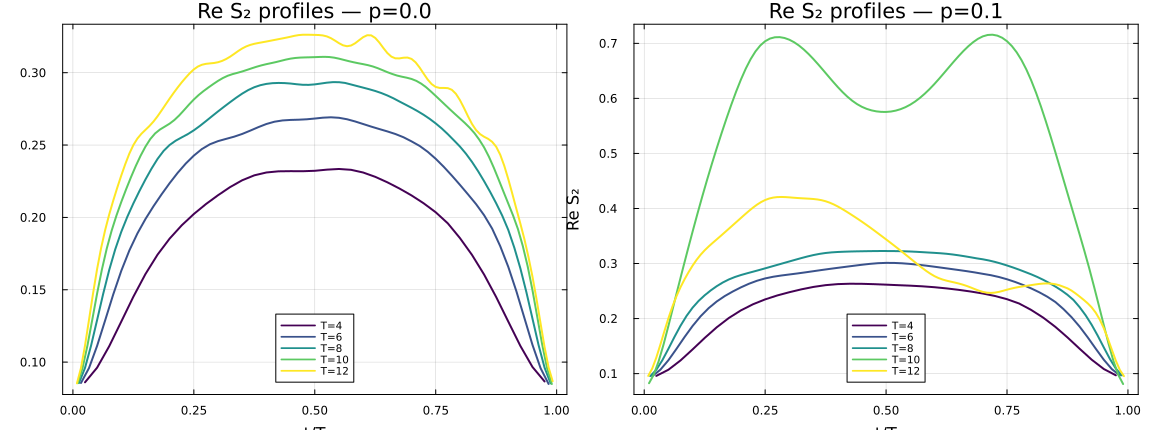

In [3]:
Tshow = [4.0, 6.0, 8.0, 10.0, 12.0]
pal = cgrad(:viridis, length(Tshow), categorical=true)
plt = plot(layout=(1,2), size=(1150,430), legendfontsize=7)
for (col,p) in enumerate(p_list)
    for (k,T) in enumerate(Tshow)
        ok(p,T) || continue
        re = real.(done[(p,T)].s2_phys); x = (1:length(re)) ./ (length(re)+1)
        plot!(plt, x, re; subplot=col, color=pal[k], lw=2, label="T=$(Int(T))",
              title="Re S₂ profiles — p=$p", xlabel="t/T", ylabel="Re S₂", framestyle=:box, legend=:bottom)
    end
end
mkpath("results/imgs"); savefig(plt, "../results/imgs/temporal_entropy_profiles.png"); plt

chord fit p=0.0 T=8: c = 8·slope = 0.730
chord fit p=0.1 T=8: c = 8·slope = 0.670


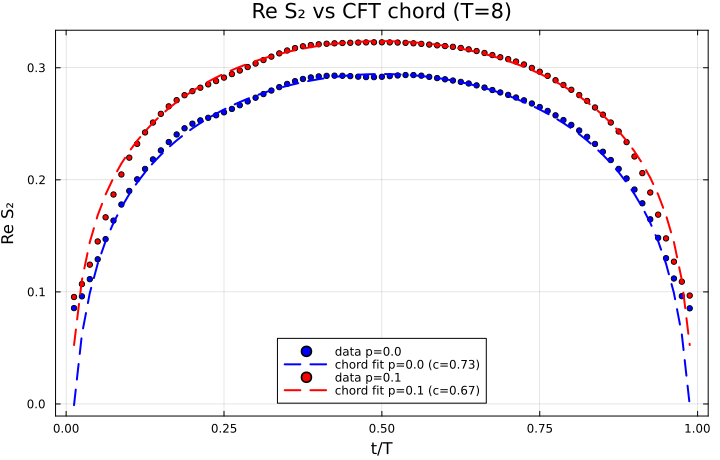

In [4]:
# Conformal check at T=8: Re S₂ vs the CFT chord law  S₂ = s0 + (c/8)·log[(2T/π)sin(πt/T)].
chord(x,T) = log((2T/pi)*sin(pi*x))
pltch = plot(size=(720,460), framestyle=:box, legend=:bottom, title="Re S₂ vs CFT chord (T=8)",
             xlabel="t/T", ylabel="Re S₂")
for (p,col) in [(0.0,:blue),(0.1,:red)]
    ok(p,8.0) || continue
    re = real.(done[(p,8.0)].s2_phys); Nb=length(re); x=(1:Nb)./(Nb+1)
    cc=chord.(x,8.0); lo=round(Int,0.25Nb)+1; hi=round(Int,0.75Nb)
    cf = hcat(ones(hi-lo+1), cc[lo:hi]) \ re[lo:hi]
    scatter!(pltch, x, re; color=col, ms=3, label="data p=$p")
    plot!(pltch, x, cf[1] .+ cf[2].*cc; color=col, ls=:dash, lw=2, label="chord fit p=$p (c=$(round(8cf[2],digits=2)))")
    @printf("chord fit p=%.1f T=8: c = 8·slope = %.3f\n", p, 8cf[2])
end
mkpath("results/imgs"); savefig(pltch, "../results/imgs/temporal_chord_fit.png"); pltch

Rényi-2 c = 8·slope   (clean window; calibration c(p=0) carries the finite-T/χ offset):
T       c0 = 8·s0     c1 = 8·s1     c1 calibrated 
2       0.3038        0.9779        1.6097        
3       0.7852        0.8510        0.5419        
4       0.7003        0.6008        0.4289        
5       0.6801        0.6264        0.4605        
6       0.6060        0.6752        0.5571        
7       0.7741        0.7358        0.4753        
8       0.7300        0.6700        0.4589        
9       0.7878        0.6639        0.4214        
10      0.6032        -4.0005       -3.3160       
11      0.6072        -3.6102       -2.9728       
12      0.6662        0.2679        0.2011        

clean-window mean (T=4..9):  c(p=0.1) = 0.467 ± 0.049


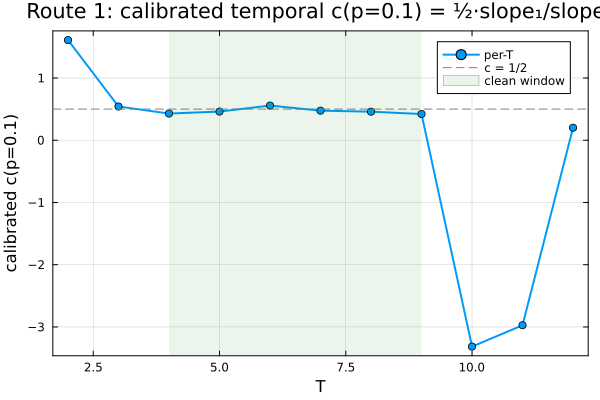

In [5]:
# c = 8·slope from the physical-λ0 domes; calibrate against p=0 → 0.5; headline = the ratio.
slope(p,T) = renyi2_slope(real.(done[(p,T)].s2_phys), T)
Tc = [T for T in Ts(0.0) if T in Ts(0.1)]

@printf("Rényi-2 c = 8·slope   (clean window; calibration c(p=0) carries the finite-T/χ offset):\n")
@printf("%-6s  %-12s  %-12s  %-14s\n","T","c0 = 8·s0","c1 = 8·s1","c1 calibrated")
cal = Float64[]; Tcal = Float64[]
for T in Tc
    s0 = slope(0.0,T); s1 = slope(0.1,T); c = 0.5*s1/s0
    @printf("%-6.0f  %-12.4f  %-12.4f  %-14.4f\n", T, 8s0, 8s1, c)
    (4.0 <= T <= 9.0) && (push!(cal, c); push!(Tcal, T))
end
@printf("\nclean-window mean (T=4..9):  c(p=0.1) = %.3f ± %.3f\n", sum(cal)/length(cal),
        sqrt(sum((cal .- sum(cal)/length(cal)).^2)/(length(cal)-1)))

pltc = plot(xlabel="T", ylabel="calibrated c(p=0.1)", framestyle=:box, grid=true, legend=:topright,
            title="Route 1: calibrated temporal c(p=0.1) = ½·slope₁/slope₀")
plot!(pltc, Tc, [0.5*slope(0.1,T)/slope(0.0,T) for T in Tc]; marker=:circle, lw=2, label="per-T")
hline!(pltc, [0.5]; ls=:dash, color=:gray, label="c = 1/2"); vspan!(pltc, [4,9]; alpha=0.08, color=:green, label="clean window")
pltc

**Route 1 result.** In the clean window $T=4\!-\!9$ the calibrated $c(p{=}0.1)\approx0.47\pm0.05$
— consistent with the Ising $1/2$. The raw $c_0(p{=}0)$ is not $0.5$ (finite-$T/\chi/\delta t$ offset),
which is exactly why $p=0$ is used as a calibration standard and the headline is the ratio. Past
$T=9$ the $p=0.1$ slope departs (the wall — notebook 5).

## Route 2 — the leading eigenvalues

A second, independent handle: the spectrum itself. We trace the physical $\lambda_0$ in the complex
plane (the **dual-unitarity circle**) and read the boundary exponent $x_1$ from the
$\lambda_1-\lambda_0$ phase (Eq. 4). The key subtlety, learned in the diagnosis below: at $p=0.1$ the
CFT descendant $\lambda_1$ is **demoted below the $-\lambda_0$ partner** in modulus, so it must be
selected by **phase** (closest to $\lambda_0$), not by modulus — which is why the $k=4$ block is needed.

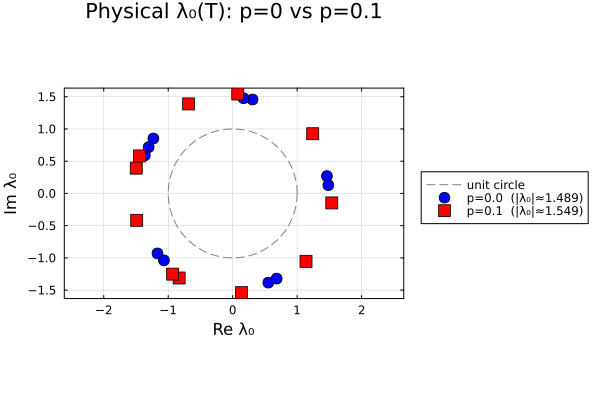

In [6]:
# Physical λ0(T) in the complex plane — near-constant radius + winding phase ⇒ emergent dual unitarity.
phi = range(0, 2pi, length=400)
plt = plot(cos.(phi), sin.(phi); ls=:dash, color=:gray, label="unit circle", aspect_ratio=:equal,
           xlabel="Re λ₀", ylabel="Im λ₀", framestyle=:box, grid=true, legend=:outerright,
           title="Physical λ₀(T): p=0 vs p=0.1")
for (p,col,mk) in zip(p_list,[:blue,:red],[:circle,:square])
    L0 = [done[(p,T)].theta_phys for T in Ts(p)]
    rbar = sum(abs,L0)/length(L0)
    scatter!(plt, real.(L0), imag.(L0); marker=mk, ms=6, color=col, label="p=$p  (|λ₀|≈$(round(rbar,digits=3)))")
end
plt

Eq.(4) boundary exponent (free-BC |X+⟩ ⇒ x1 ≈ 1/2):
  p=0    : x1 = 0.498  (a1=0.782; paper free-BC a1≈π/4=0.785)
  p=0.1  : x1 = 1.481  (a1=2.326)


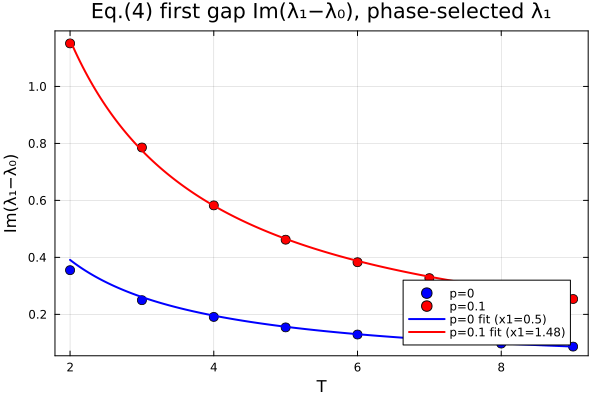

In [7]:
# Eq.(4): Im(λ1−λ0) = −π x1/(vT).  λ1 = the descendant phase-CLOSEST to λ0 (reject −λ0 partner).
# Fit a1/T + a3/T³ over the converged window; x1 = |v·a1/π|. Free-BC |X+⟩ ⇒ target x1 ≈ 1/2.
lam1_cft(e) = (cand=[j for j in 1:length(e.theta) if j != e.i0];
               e.theta[cand[argmin([abs(dphw(e.theta[j], e.theta_phys)) for j in cand])]])
function eq4(p; Tmax=9.0)
    Tg = [T for T in Ts(p) if T <= Tmax]              # converged / pre-wall window
    g  = [dphw(lam1_cft(done[(p,T)]), done[(p,T)].theta_phys) for T in Tg]
    @. mg(T,q) = q[1]/T + q[2]/T^3
    f = curve_fit(mg, Float64.(Tg), g, [-1.0, 0.0])
    (; Tg, g, a1=f.param[1], x1=abs(v*f.param[1]/pi))
end
e0 = eq4(0.0); e1 = eq4(0.1)
@printf("Eq.(4) boundary exponent (free-BC |X+⟩ ⇒ x1 ≈ 1/2):\n")
@printf("  p=0    : x1 = %.3f  (a1=%.3f; paper free-BC a1≈π/4=%.3f)\n", e0.x1, e0.a1, pi/4)
@printf("  p=0.1  : x1 = %.3f  (a1=%.3f)\n", e1.x1, e1.a1)

plt = plot(title="Eq.(4) first gap Im(λ₁−λ₀), phase-selected λ₁", xlabel="T", ylabel="Im(λ₁−λ₀)",
           framestyle=:box, grid=true, legend=:bottomright)
scatter!(plt, e0.Tg, e0.g; label="p=0", color=:blue, ms=5)
scatter!(plt, e1.Tg, e1.g; label="p=0.1", color=:red, ms=5)
mg4(T,q)=q[1]./T .+ q[2]./T.^3; Td=range(2, 9, length=200)
plot!(plt, Td, mg4(Td,[e0.a1,0.0]); color=:blue, lw=2, label="p=0 fit (x1=$(round(e0.x1,digits=2)))")
plot!(plt, Td, mg4(Td,[e1.a1,0.0]); color=:red,  lw=2, label="p=0.1 fit (x1=$(round(e1.x1,digits=2)))")
plt

**Route 2 result — validates the framework on $p=0$, contaminated for $p=0.1$.**

- The $\lambda_0$ **circle** has near-constant radius with a winding phase — the fingerprint of the
  transfer matrix approaching a *rescaled unitary* (emergent **dual unitarity**), for **both** $p$.
- The boundary exponent on the integrable point is textbook: $x_1(p{=}0)=0.498$, $a_1\approx\pi/4$ —
  exactly the **free-BC Ising** value, confirming $|X+\rangle$ is the free boundary and that the
  pipeline is correct where the spectrum is well separated.
- But $x_1(p{=}0.1)\approx1.5$, **not** $1/2$. This is *not* a clean boundary exponent: at the
  near-degeneracy the CFT descendant $\lambda_1$ (and even the physical-$\lambda_0$ *selection*) is
  ambiguous when several $|\theta|$ are nearly equal, so both Eq. (4) ($x_1$) and Eq. (3) ($c$ from the
  $\mathrm{Im}\,\lambda_0$ curvature) are contaminated for the frustrated model.

So the eigenvalues **corroborate the framework** (correct on $p=0$; dual unitarity for both $p$) but do
**not** deliver a clean quantitative $c$ or $x_1$ at $p=0.1$. Why the eigenvalue *selection* fails for
the frustrated model — while it works for the well-separated $p=0$ — is the subject of **notebook 5**.

## Verdict

| route | observable | $p=0$ (calibration) | $p=0.1$ | status |
|---|---|---|---|---|
| 1 — entropy slope | $c = 8\cdot\text{slope}$ | raw $c_0\approx0.7$–$0.9$ | **$c = 0.47\pm0.05$** (clean window $T{=}4\!-\!9$) | ✅ the headline |
| 2 — dual unitarity | $\lambda_0$ circle | near-const $\|\lambda_0\|$, winding | same | ✅ both $p$ |
| 2 — boundary exponent | $x_1$ (Eq. 4) | $x_1=0.498$ (free-BC Ising) | $x_1\approx1.5$ | ❌ contaminated at $p{=}0.1$ |

**The result.** Via the entropy-slope route — the one channel that is controlled at the gap closing —
the temporal central charge is $c(p{=}0.1)=0.47\pm0.05$, consistent with the Ising $1/2$. The framework
is independently validated by Route 2 on the integrable point ($x_1=0.498$, the $\lambda_0$ circle) and
exhibits emergent dual unitarity for both $p$. **Temporal Ising universality survives the NNN
frustration at $p=0.1$.**

**Honest caveats.** (i) This is a *calibrated ratio* at a single $p$ — it assumes $v=2$ and
$c(p{=}0)\equiv1/2$; a full $p$-sweep / breaking-point $p^\*$ is future work. (ii) Only Route 1 gives a
clean *quantitative* $p=0.1$ number; the eigenvalue routes (Eq. 3 $c$, Eq. 4 $x_1$) are contaminated for
the frustrated model because the physical-$\lambda_0$/$\lambda_1$ *selection* is ambiguous at the
near-degeneracy. (iii) The extraction lives in the **pre-wall window** $T\lesssim9$. Why that wall is
fundamental — and why neither the entropy nor the eigenvalue channel beats it for the asymmetric,
frustrated model — is the subject of **notebook 5**.